# PyMC-13 : Crowdsourcing - Agregation de Labels et Fiabilite

**Navigation** : [Index](../README.md) | [<< PyMC-12](PyMC-12-Modeles-Hierarchiques.ipynb)

**Serie** : Programmation Probabiliste avec PyMC (13/20)

**Duree estimee** : 55 minutes

**Objectifs d'apprentissage** :
- Comprendre le problème de l'agregation de labels en crowdsourcing
- Implementer les modèles Honest Worker et Biased Worker avec PyMC
- Explorer le modèle hiérarchique Community pour les groupes d'annotateurs
- Appliquer l'apprentissage actif via l'echantillonnage d'incertitude

**Prerequis** : PyMC-1 a PyMC-11, bases de statistique bayesienne

**Correspondance Infer.NET** : [Infer-13-Crowdsourcing](../Infer/Infer-13-Crowdsourcing.ipynb)

In [1]:
# Dependances : installer silencieusement seulement ce qui manque.
# (import-guards deterministes : pas de sortie bruyante 'Requirement already satisfied'
#  qui fuie le chemin machine, cf #3436 cause A.)
import importlib, subprocess, sys
_MISSING = [pkg for pkg in ("pymc", "arviz", "matplotlib", "numpy", "scipy") if importlib.util.find_spec(pkg) is None]
if _MISSING:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_MISSING], check=True)
    print("Paquets installes :", ", ".join(_MISSING))
else:
    print("Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.")


Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.


### Import des bibliotheques

Les bibliotheques PyMC, ArviZ et NumPy sont chargees avec gestion des imports optionnels.

In [2]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MPL_AVAILABLE = True
except ImportError:
    MPL_AVAILABLE = False

import scipy.stats as stats

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print(f"NumPy version: {np.__version__}")
print("\nTous les packages necessaires sont charges.")

PyMC version: 6.3.1
ArviZ version: 1.1.0
NumPy version: 2.5.3

Tous les packages necessaires sont charges.


## 1. Le Problème du Crowdsourcing

### Contexte

**Pourquoi ce probleme compte.** Le chapitre 7 « Harnessing the Crowd » de *Model-Based Machine Learning* (Winn & Bishop), dont cette serie est distillee, ouvre sur un cas concret : lors du **seisme de 2010 en Haiti** (magnitude 7.0), des dizaines de milliers de messages, SMS et tweets envoyes depuis le terrain ont ete tries et categorises a la main par des volontaires aux competences et biais variables. La plateforme **Ushahidi** (« temoignage » en swahili), creee en **2008** lors des violences post-electorales au Kenya pour cartographier les temoignages, y a ete deployee pour collecter et diffuser l'information de crise (utilisee par l'armee, l'ONU et les ONG). Le defi : a partir de **rapports contradictoires et bruites** emanant de travailleurs de fiabilite inegale, **inferer la situation reelle sur le terrain**. C'est precisement le probleme modelise dans ce notebook. Le meme principe s'applique a des taches plus routinieres.

On veut annoter un grand nombre d'items (images, textes, etc.) en utilisant des travailleurs de qualite variable. Le defi est d'agreger ces annotations pour inferer les vrais labels.

### Formalisation mathematique

**Variables observees** : $l_{ij} \in \{1, \ldots, K\}$ le label donne par le travailleur $j$ pour l'item $i$

**Variables latentes** :
- $t_i \in \{1, \ldots, K\}$ le vrai label de l'item $i$
- $\theta_j$ la fiabilite du travailleur $j$

**Objectif** : estimer $P(t_i | l_{1:N, 1:M})$ en integrant l'incertitude sur les fiabilites.

### Sources canoniques

Ce notebook s'inscrit dans la tradition de l'inférence par maximum de vraisemblance puis bayésienne pour les réponses d'annotateurs multiples, développée ici en **PyMC** pour sa formulation probabiliste moderne (variables latentes + MCMC / EM).

| Source | Année | Rôle dans ce notebook |
|--------|-------|----------------------|
| Dawid & Skene, *Maximum likelihood estimation of observer error-rates using the EM algorithm*, JRSS-A | 1979 | Inspire les modèles de matrice de confusion par worker (Honest Worker, Biased Worker) — cf. section 5 |
| Raykar et al., *Learning from Crowds*, JMLR 11:1297-1332 | 2010 | Formalisation bayésienne du prior sur la matrice de confusion, inspire le modèle Biased Worker |
| Karger, Oh & Shah, *Iterative Learning from Crowds*, NIPS Workshop on Crowdsourcing | 2011 | Algorithme itératif pour l'apprentissage actif avec convergence garantie |
| Whitehill et al., *Whose Vote Should Count More*, NIPS | 2009 | GLAD : ajoute la difficulté par item |
| Kim & Ghahramani, *Bayesian Classifier Combination*, ICML | 2012 | BCC = version bayésienne de Dawid-Skene |
| MBML Book, *Harnessing the Crowd* (Chap. 7) | en ligne | Présentation pédagogique d'ensemble sur mbmlbook.com — cf. contexte §1 |

> **Note de fidélité** : le notebook développe les formalismes en PyMC (MCMC `CategoricalGibbsMetropolis` pour les labels discrets, EM pour Dawid-Skene), pas avec les algorithmes EM historiques de Dawid-Skene 1979. Les **équations** sont alignées sur Dawid-Skene 1979 et Raykar 2010 ; les **choix d'architecture** (Beta prior, Dirichlet confusion matrix, hiérarchie Community) reflètent la pratique probabiliste moderne issue de Raykar 2010 et Karger 2011.

## 2. Données de Crowdsourcing

Nous utilisons un petit jeu de données avec 5 items, 4 travailleurs et 2 classes pour illustrer les modèles.

In [3]:
# Donnees de crowdsourcing
# 5 items, 4 workers, 2 classes (0 ou 1)

n_items = 5
n_workers = 4
n_classes = 2

# Labels donnes par chaque worker pour chaque item
#            W1  W2  W3  W4
labels = np.array([
    [1,  1,  1,  0],   # Item 0 : consensus 1
    [0,  0,  0,  0],   # Item 1 : consensus 0
    [1,  1,  0,  1],   # Item 2 : majorite 1
    [0,  1,  0,  0],   # Item 3 : majorite 0
    [1,  0,  1,  1]    # Item 4 : majorite 1
])

# Vrais labels (pour evaluation - inconnus du modele)
vrais_labels = np.array([1, 0, 1, 0, 1])

print("=== Donnees Crowdsourcing ===")
print("\nLabels donnes par les workers :")
header = "        " + "  ".join([f"W{w+1}" for w in range(n_workers)]) + " | Vrai"
print(header)
for i in range(n_items):
    row = f"Item {i} : " + "  ".join([f" {labels[i,w]}" for w in range(n_workers)]) + f" |  {vrais_labels[i]}"
    print(row)

# Analyse rapide des accords
for i in range(n_items):
    votes = labels[i]
    n0 = np.sum(votes == 0)
    n1 = np.sum(votes == 1)
    accord = "consensus" if n0 == 0 or n1 == 0 else "desaccord"
    print(f"Item {i} : {n0} votes 0, {n1} votes 1 ({accord})")

=== Donnees Crowdsourcing ===

Labels donnes par les workers :
        W1  W2  W3  W4 | Vrai
Item 0 :  1   1   1   0 |  1
Item 1 :  0   0   0   0 |  0
Item 2 :  1   1   0   1 |  1
Item 3 :  0   1   0   0 |  0
Item 4 :  1   0   1   1 |  1
Item 0 : 1 votes 0, 3 votes 1 (desaccord)
Item 1 : 4 votes 0, 0 votes 1 (consensus)
Item 2 : 1 votes 0, 3 votes 1 (desaccord)
Item 3 : 3 votes 0, 1 votes 1 (desaccord)
Item 4 : 1 votes 0, 3 votes 1 (desaccord)


### Lecture des données

Le tableau montre un scénario typique de crowdsourcing :

| Pattern | Items | Observation |
|---------|-------|-------------|
| Consensus (4/4) | Item 1 | Les 4 workers d'accord, haute confiance |
| Majorite (3/1) | Item 0, 2, 3, 4 | Un worker diverge, le modèle doit ponderer |

Sur chaque item en desaccord (3/1), exactement un worker se trompe : le Worker 4 sur l'Item 0 (W4=0 alors que vrai=1), le Worker 3 sur l'Item 2 (W3=0 alors que vrai=1), et le Worker 2 sur les Items 3 et 4. W2 cumule deux erreurs sur cinq --- c'est le worker le plus souvent en desaccord, un bon candidat pour tester la detection de workers biaisés.

## 3. Vote Majoritaire (Baseline)

Avant d'utiliser des modèles bayesiens, etablissons une baseline avec le vote majoritaire.

In [4]:
# Vote majoritaire (baseline)
print("=== Vote Majoritaire (Baseline) ===")

predictions_mv = []
for i in range(n_items):
    votes = labels[i]
    n0 = np.sum(votes == 0)
    n1 = np.sum(votes == 1)
    pred = 1 if n1 > n0 else 0
    predictions_mv.append(pred)
    correct = "OK" if pred == vrais_labels[i] else "ERREUR"
    print(f"Item {i} : votes [0:{n0}, 1:{n1}] -> pred={pred}, vrai={vrais_labels[i]} [{correct}]")

accuracy_mv = np.mean(np.array(predictions_mv) == vrais_labels)
print(f"\nPrecision vote majoritaire : {accuracy_mv:.1%} ({np.sum(np.array(predictions_mv) == vrais_labels)}/{n_items})")

=== Vote Majoritaire (Baseline) ===
Item 0 : votes [0:1, 1:3] -> pred=1, vrai=1 [OK]
Item 1 : votes [0:4, 1:0] -> pred=0, vrai=0 [OK]
Item 2 : votes [0:1, 1:3] -> pred=1, vrai=1 [OK]
Item 3 : votes [0:3, 1:1] -> pred=0, vrai=0 [OK]
Item 4 : votes [0:1, 1:3] -> pred=1, vrai=1 [OK]

Precision vote majoritaire : 100.0% (5/5)


### Analyse du vote majoritaire

Le vote majoritaire donne une première estimation mais traite tous les workers de maniere egale. Si un worker est systematiquement mauvais, son vote a le même poids que celui d'un expert.

### Exercice 1 : Vote Majoritaire Pondere

Implementez un vote majoritaire pondere ou le vote de chaque worker est pondere par son accuracy connue (calculee sur les 5 items). Comparez la precision avec le vote majoritaire simple.

**Objectif** : Comprendre l'impact de la ponderation par fiabilite.

**Indices** :
- Calculez l'accuracy de chaque worker par rapport aux vrais labels
- Pour chaque item, somme ponderee : `score = sum(weight[w] * (labels[i,w] == 1))`
- Si `score > sum(weight) / 2`, predisez 1, sinon 0

In [5]:
# Exercice 1 : Vote majoritaire pondere
# Ponderez chaque vote par l'accuracy du worker et comparez au MV simple

# TODO etudiant : calculer l'accuracy de chaque worker,
# puis implementer le vote pondere

weighted_predictions = None  # TODO etudiant : predictions ponderees
print("Exercice a completer")

Exercice a completer


## 4. Modèle Honest Worker

### Hypothese

Chaque travailleur a une **capacite** $\theta_j \in [0, 1]$ (probabilite de donner la bonne reponse).

$$\text{capacite}_j \sim \text{Beta}(a, b)$$
$$P(l_{ij} = t_i) = \text{capacite}_j$$

### Structure du modèle

```
            Beta(a,b)
                |
           capacite_j
                |
        Bernoulli(capacite_j)
                |
          est_correct_j
           /         \
     vrai_label     1-vrai_label
          \           /
          label_obs_j
```

In [6]:
# Modele Honest Worker avec PyMC
# Pour chaque item, on estime le vrai label en tenant compte des capacites

def honest_worker_model(labels_matrix, n_classes=2, alpha_prior=2, beta_prior=1):
    """
    Modele Honest Worker : chaque worker a une capacite scalaire.
    
    Parametres :
        labels_matrix : array (n_items, n_workers) avec les labels observes
        n_classes : nombre de classes
        alpha_prior, beta_prior : hyperparametres du prior Beta sur la capacite
    """
    n_items, n_workers = labels_matrix.shape
    
    with pm.Model() as model:
        # Prior uniforme sur les vrais labels
        true_labels = pm.Categorical("true_labels", p=np.ones(n_classes) / n_classes,
                                     shape=n_items)
        
        # Capacite de chaque worker (Beta prior)
        capacity = pm.Beta("capacity", alpha=alpha_prior, beta=beta_prior,
                          shape=n_workers)
        
        # Pour chaque paire (item, worker), le label observe depend de :
        # - le vrai label de l'item
        # - la capacite du worker
        # Approche : probabilite de donner le vrai label = capacity,
        # probabilite de donner l'autre label = 1 - capacity
        
        # Construction des probabilites d'observation
        # p_obs[i,w] = probabilite que worker w donne le label observe pour item i
        # Si labels_matrix[i,w] == true_labels[i] : p = capacity[w]
        # Sinon : p = 1 - capacity[w]
        
        # Vectorisation : on construit les probas pour Bernoulli
        # On encode le label observe comme match (1) ou mismatch (0)
        # et on modelise si le worker est correct
        
        # Approche simplifiee pour 2 classes :
        # Le worker repond correctement avec proba = capacity
        # Le label observe est : true_label si correct, (1-true_label) si incorrect
        
        is_correct = pm.Bernoulli("is_correct", p=capacity,
                                  shape=(n_items, n_workers))
        
        # Label observe = true_label si correct, sinon l'autre classe
        observed_labels = pm.Deterministic("obs_labels",
            is_correct * true_labels[:, None] +
            (1 - is_correct) * (1 - true_labels[:, None])
        )
    
    return model


# Application sur l'Item 2 (desaccord)
item_idx = 2
print(f"=== Modele Honest Worker pour Item {item_idx} ===")
print(f"Labels observes : {labels[item_idx]}")
print(f"Vrai label : {vrais_labels[item_idx]}")

print("\nModele Honest Worker construit.")
print("(L'estimation complete est effectuee dans la cellule suivante)")


=== Modele Honest Worker pour Item 2 ===
Labels observes : [1 1 0 1]
Vrai label : 1

Modele Honest Worker construit.
(L'estimation complete est effectuee dans la cellule suivante)


### Modèle Honest Worker complet avec echantillonnage

Pour le cas a 2 classes, on peut implementer une version plus directe du modèle Honest Worker en utilisant une approche probabiliste simplifiee.

In [7]:
# Modele Honest Worker complet avec estimation sur tous les items
# Approche : estimation des capacites puis prediction des vrais labels

print("=== Modele Honest Worker (estimation des capacites) ===")

# Etape 1 : Estimer les capacites des workers
# En supposant les vrais labels connus pour calibration
worker_accuracy = []
for w in range(n_workers):
    correct = np.sum(labels[:, w] == vrais_labels)
    total = n_items
    acc = correct / total
    worker_accuracy.append(acc)
    print(f"Worker {w+1} : {correct}/{total} corrects = {acc:.2f}")

# Etape 2 : Estimation bayesienne des capacites
# Prior Beta(2, 1) + likelihood Bernoulli
print("\n--- Estimation bayesienne des capacites ---")
alpha_prior, beta_prior = 2, 1

for w in range(n_workers):
    n_correct = np.sum(labels[:, w] == vrais_labels)
    n_incorrect = n_items - n_correct
    # Posterior Beta(alpha + n_correct, beta + n_incorrect)
    alpha_post = alpha_prior + n_correct
    beta_post = beta_prior + n_incorrect
    mean_post = alpha_post / (alpha_post + beta_post)
    ci_low = stats.beta.ppf(0.025, alpha_post, beta_post)
    ci_high = stats.beta.ppf(0.975, alpha_post, beta_post)
    print(f"Worker {w+1} : Beta({alpha_post},{beta_post}), "
          f"moyenne={mean_post:.3f}, IC 95%=[{ci_low:.3f}, {ci_high:.3f}]")

# Etape 3 : Prediction des vrais labels par ponderation bayesienne
print("\n--- Prediction des vrais labels ---")
predictions_hw = []
for i in range(n_items):
    # P(vrai=1 | labels, capacites) par regle de Bayes simplifiee
    log_odds = 0  # log(P(vrai=1)/P(vrai=0))
    for w in range(n_workers):
        cap = worker_accuracy[w]
        if labels[i, w] == 1:
            log_odds += np.log(cap / (1 - cap + 1e-10) + 1e-10)
        else:
            log_odds += np.log((1 - cap) / (cap + 1e-10) + 1e-10)
    
    prob_1 = 1 / (1 + np.exp(-log_odds))
    pred = 1 if prob_1 > 0.5 else 0
    predictions_hw.append(pred)
    correct = "OK" if pred == vrais_labels[i] else "ERREUR"
    print(f"Item {i} : P(vrai=1)={prob_1:.3f} -> pred={pred}, vrai={vrais_labels[i]} [{correct}]")

accuracy_hw = np.mean(np.array(predictions_hw) == vrais_labels)
print(f"\nPrecision Honest Worker : {accuracy_hw:.1%}")

=== Modele Honest Worker (estimation des capacites) ===
Worker 1 : 5/5 corrects = 1.00
Worker 2 : 3/5 corrects = 0.60
Worker 3 : 4/5 corrects = 0.80
Worker 4 : 4/5 corrects = 0.80

--- Estimation bayesienne des capacites ---
Worker 1 : Beta(7,1), moyenne=0.875, IC 95%=[0.590, 0.996]
Worker 2 : Beta(5,3), moyenne=0.625, IC 95%=[0.290, 0.901]
Worker 3 : Beta(6,2), moyenne=0.750, IC 95%=[0.421, 0.963]
Worker 4 : Beta(6,2), moyenne=0.750, IC 95%=[0.421, 0.963]

--- Prediction des vrais labels ---
Item 0 : P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 1 : P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 2 : P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 3 : P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 4 : P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]

Precision Honest Worker : 100.0%


### Interpretation du modèle Honest Worker

Le modèle Honest Worker attribue une capacite unique a chaque travailleur. L'estimation bayesienne combine le prior (Beta) avec les observations pour obtenir une distribution posterieure sur la capacite de chaque worker.

**Limitation** : un worker peut etre bon pour detecter la classe 0 mais mauvais pour la classe 1. Le modèle Honest Worker ne capture pas cette nuance.

### Exercice 2 : Posterior Beta du Worker 2

Le Worker 2 a une accuracy de 60%. Tracez le prior `Beta(2, 1)` et le posterior `Beta(2 + n_correct, 1 + n_incorrect)` sur le même graphique. Commentez l'incertitude residuelle.

**Objectif** : Visualiser comment les observations resserrent le posterior par rapport au prior.

**Indices** :
- `scipy.stats.beta.pdf(x, alpha, beta)` pour tracer les densites
- Le prior est `Beta(2, 1)`, le posterior depend du nombre de correct/incorrect
- Utilisez `np.linspace(0, 1, 200)` pour l'axe x

In [8]:
# Exercice 2 : Posterior Beta du Worker 2
# Tracez prior et posterior pour la capacite du Worker 2

# TODO etudiant : calculer n_correct et n_incorrect pour W2,
# tracer les deux densites Beta sur le meme graphique,
# et commenter l'incertitude residuelle

x = np.linspace(0, 1, 200)
print("Exercice a completer")

Exercice a completer


## 5. Modèle Biased Worker (Dawid-Skene)

### Amelioration

Au lieu d'une simple capacite scalaire, chaque worker a une **matrice de confusion** $C_j$ qui capture ses biais spécifiques.

$$C_j[k, :] \sim \text{Dirichlet}(\alpha_k)$$
$$P(l_{ij} = k' | t_i = k) = C_j[k, k']$$

### Comparaison Honest vs Biased Worker

| Aspect | Honest Worker | Biased Worker |
|--------|---------------|---------------|
| Paramètres par worker | 1 (capacite) | $K^2$ (matrice de confusion) |
| Capture les biais | Non | Oui |
| Complexite | Faible | Moyenne |

In [9]:
# Modele Biased Worker : estimation de la matrice de confusion
# On estime la matrice de confusion du Worker 4 (W4) qui semble avoir des biais

print("=== Modele Biased Worker ===")
print("\nAnalyse du Worker 4 (W4) :")
w4_labels = labels[:, 3]
print(f"Labels W4 : {w4_labels}")
print(f"Vrais     : {vrais_labels}")

# Calcul empirique de la matrice de confusion
confusion_empirical = np.zeros((n_classes, n_classes))
for i in range(n_items):
    vrai = vrais_labels[i]
    pred = w4_labels[i]
    confusion_empirical[vrai, pred] += 1

# Normalisation par ligne
confusion_normalized = confusion_empirical / confusion_empirical.sum(axis=1, keepdims=True)

print(f"\nMatrice de confusion empirique de W4 :")
print(f"              Pred 0   Pred 1")
for k in range(n_classes):
    print(f"Vrai {k} :    {confusion_empirical[k,0]:.0f}/{confusion_empirical[k].sum():.0f}"
          f"     {confusion_empirical[k,1]:.0f}/{confusion_empirical[k].sum():.0f}")

print(f"\nMatrice normalisee :")
print(f"              Pred 0   Pred 1")
for k in range(n_classes):
    print(f"Vrai {k} :    {confusion_normalized[k,0]:.3f}     {confusion_normalized[k,1]:.3f}")

# Estimation bayesienne avec prior Dirichlet
print("\n--- Estimation bayesienne (prior Dirichlet) ---")
dirichlet_prior = np.array([10, 1])  # Prior : tendance a repondre correctement

for k in range(n_classes):
    # Posterior Dirichlet(prior + counts)
    alpha_post = dirichlet_prior + confusion_empirical[k]
    mean_post = alpha_post / alpha_post.sum()
    print(f"Vrai {k} -> Dirichlet({alpha_post[0]:.0f},{alpha_post[1]:.0f}), "
          f"P(pred=0)={mean_post[0]:.3f}, P(pred=1)={mean_post[1]:.3f}")

=== Modele Biased Worker ===

Analyse du Worker 4 (W4) :
Labels W4 : [0 0 1 0 1]
Vrais     : [1 0 1 0 1]

Matrice de confusion empirique de W4 :
              Pred 0   Pred 1
Vrai 0 :    2/2     0/2
Vrai 1 :    1/3     2/3

Matrice normalisee :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.333     0.667

--- Estimation bayesienne (prior Dirichlet) ---
Vrai 0 -> Dirichlet(12,1), P(pred=0)=0.923, P(pred=1)=0.077
Vrai 1 -> Dirichlet(11,3), P(pred=0)=0.786, P(pred=1)=0.214


### Analyse du modèle Biased Worker

La matrice de confusion revele les biais spécifiques de chaque worker. Par exemple, W4 peut etre bon pour detecter la classe 0 mais systematiquement mauvais pour la classe 1. Le modèle Dawid-Skene utilise ces matrices pour ponderer les annotations de maniere plus fine que le modèle Honest Worker.

In [10]:
# Modele Dawid-Skene simplifie avec PyMC
# Estimation conjointe des vrais labels et des matrices de confusion

print("=== Modele Dawid-Skene avec PyMC ===")

with pm.Model() as dawid_skene:
    # Prior uniforme sur les vrais labels
    true_labels = pm.Categorical("true_labels", p=np.ones(n_classes) / n_classes,
                                 shape=n_items)
    
    # Matrice de confusion par worker (Dirichlet prior par ligne)
    # confusion[w] : matrice (n_classes, n_classes) pour le worker w
    # confusion[w, k, :] = distribution sur les labels predits quand vrai=k
    dirichlet_concentration = np.array([[5, 1], [1, 5]])  # Tendance a etre correct
    
    # On parametrise avec un Dirichlet par (worker, vrai_label)
    confusion = pm.Dirichlet("confusion", a=dirichlet_concentration,
                            shape=(n_workers, n_classes, n_classes))
    
    # Likelihood : pour chaque (item, worker), observer le label
    # P(label[w,i] = l | true_label[i] = k) = confusion[w, k, l]
    # On utilise pm.Categorical avec les probabilites indexees
    
print("Modele Dawid-Skene construit.")
print("(L'echantillonnage est effectue via EM dans la cellule suivante pour la stabilite)")

=== Modele Dawid-Skene avec PyMC ===


Modele Dawid-Skene construit.


(L'echantillonnage est effectue via EM dans la cellule suivante pour la stabilite)


### Implementation EM du Dawid-Skene

L'algorithme EM (Expectation-Maximization) est plus stable que l'echantillonnage MCMC pour le modèle Dawid-Skene. Il alterne entre l'estimation des vrais labels (E-step) et la mise a jour des matrices de confusion (M-step).

In [11]:
# Implementation EM du Dawid-Skene (plus stable que MCMC pour ce modele)

def dawid_skene_em(labels_matrix, n_classes=2, n_iter=20, tol=1e-6):
    """
    Algorithme EM pour le modele Dawid-Skene.
    
    Parametres :
        labels_matrix : array (n_items, n_workers)
        n_classes : nombre de classes
        n_iter : nombre max d'iterations
        tol : seuil de convergence
    
    Retourne :
        class_probs : P(vrai_label | labels) pour chaque item
        confusion_matrices : matrices de confusion estimees par worker
    """
    n_items, n_workers = labels_matrix.shape
    
    # Initialisation : vote majoritaire pour estimer les probabilites
    class_probs = np.zeros((n_items, n_classes))
    for i in range(n_items):
        for k in range(n_classes):
            class_probs[i, k] = np.mean(labels_matrix[i] == k)
    # Lisser
    class_probs = np.clip(class_probs, 0.01, 0.99)
    class_probs /= class_probs.sum(axis=1, keepdims=True)
    
    # Initialiser les matrices de confusion a des valeurs raisonnables
    confusion_matrices = np.ones((n_workers, n_classes, n_classes)) * 0.1
    for w in range(n_workers):
        for k in range(n_classes):
            confusion_matrices[w, k, k] = 0.8  # Diagonale dominante
        # Normaliser par ligne
        confusion_matrices[w] /= confusion_matrices[w].sum(axis=1, keepdims=True)
    
    for iteration in range(n_iter):
        # E-step : mettre a jour les probabilites des vrais labels
        new_class_probs = np.ones((n_items, n_classes)) / n_classes  # prior uniforme
        
        for w in range(n_workers):
            for k in range(n_classes):
                for i in range(n_items):
                    l = labels_matrix[i, w]
                    new_class_probs[i, k] *= confusion_matrices[w, k, l]
        
        # Normaliser
        new_class_probs /= new_class_probs.sum(axis=1, keepdims=True)
        
        # M-step : mettre a jour les matrices de confusion
        new_confusion = np.zeros((n_workers, n_classes, n_classes))
        for w in range(n_workers):
            for k in range(n_classes):
                for l in range(n_classes):
                    mask = (labels_matrix[:, w] == l)
                    new_confusion[w, k, l] = np.sum(new_class_probs[mask, k])
            # Normaliser par ligne
            new_confusion[w] /= new_confusion[w].sum(axis=1, keepdims=True)
        
        # Verifier convergence
        diff = np.max(np.abs(new_class_probs - class_probs))
        class_probs = new_class_probs
        confusion_matrices = new_confusion
        
        if diff < tol:
            print(f"Convergence a l'iteration {iteration + 1}")
            break
    
    return class_probs, confusion_matrices


# Executer Dawid-Skene EM
class_probs, confusion_est = dawid_skene_em(labels, n_classes=2)

print("\n--- Resultats Dawid-Skene ---")
predictions_ds = np.argmax(class_probs, axis=1)
for i in range(n_items):
    correct = "OK" if predictions_ds[i] == vrais_labels[i] else "ERREUR"
    print(f"Item {i} : P(vrai=0)={class_probs[i,0]:.3f}, P(vrai=1)={class_probs[i,1]:.3f}"
          f" -> pred={predictions_ds[i]}, vrai={vrais_labels[i]} [{correct}]")

accuracy_ds = np.mean(predictions_ds == vrais_labels)
print(f"\nPrecision Dawid-Skene : {accuracy_ds:.1%}")

print("\n--- Matrices de confusion estimees ---")
for w in range(n_workers):
    print(f"\nWorker {w+1} :")
    print(f"              Pred 0   Pred 1")
    for k in range(n_classes):
        print(f"Vrai {k} :    {confusion_est[w,k,0]:.3f}     {confusion_est[w,k,1]:.3f}")

Convergence a l'iteration 6



--- Resultats Dawid-Skene ---
Item 0 : P(vrai=0)=0.000, P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 1 : P(vrai=0)=1.000, P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 2 : P(vrai=0)=0.000, P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]
Item 3 : P(vrai=0)=1.000, P(vrai=1)=0.000 -> pred=0, vrai=0 [OK]
Item 4 : P(vrai=0)=0.000, P(vrai=1)=1.000 -> pred=1, vrai=1 [OK]

Precision Dawid-Skene : 100.0%

--- Matrices de confusion estimees ---

Worker 1 :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.000     1.000

Worker 2 :
              Pred 0   Pred 1
Vrai 0 :    0.500     0.500
Vrai 1 :    0.333     0.667

Worker 3 :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.333     0.667

Worker 4 :
              Pred 0   Pred 1
Vrai 0 :    1.000     0.000
Vrai 1 :    0.333     0.667


### Quand Dawid-Skene surpasse-t-il VRAIMENT le vote majoritaire ?

Sur le jeu de données ci-dessus (§5), le vote majoritaire et Dawid-Skene atteignent **tous les deux 100 %** de précision : les quatre workers sont fiables, le problème est trop facile pour que le modèle de Dawid-Skene montre sa valeur. La table de comparaison ci-dessous affirme « Dawid-Skene souvent meilleur », mais rien dans les sorties commitées ne le **démontre** — les deux méthodes y sont ex aequo.

Pour rendre la capacité distinctive de Dawid-Skene **visible dans les nombres**, il faut un problème où le vote majoritaire a quelque chose à **perdre** : un jeu de données contaminé par des *workers biaisés*. C'est précisément la situation omniprésente dans le vrai crowdsourcing (annotateurs inattentifs, bots, spammeurs). Construisons ce cas : 3 workers fiables + 2 « spammers » qui votent toujours 1.

In [12]:
# --- Cas discriminant : workers biaisés (le vote majoritaire echoue) ---
# Sur le jeu de donnees precedent (section 5), Dawid-Skene ET le vote majoritaire
# atteignent 100 % : les workers sont fiables, le probleme est trop facile pour
# que le modele de Dawid-Skene montre sa valeur. Construisons un cas ou des
# workers biaisés (des "spammers" qui votent toujours 1) font echouer le vote
# majoritaire, et regardons si Dawid-Skene recupere les vrais labels.

# 3 workers fiables (avec quelques erreurs honnetes) + 2 spammers (toujours 1)
vrais_labels_biais = np.array([1, 0, 1, 0, 1, 0, 1, 0])
n_items_biais = len(vrais_labels_biais)
W1 = vrais_labels_biais.copy()              # worker fiable parfait
W2 = vrais_labels_biais.copy(); W2[3] = 1   # erreur honnete (vrai=0 -> 1)
W3 = vrais_labels_biais.copy(); W3[7] = 1   # erreur honnete (vrai=0 -> 1)
W4 = np.ones(n_items_biais, dtype=int)      # spammer : vote toujours 1
W5 = np.ones(n_items_biais, dtype=int)      # spammer : vote toujours 1
labels_biais = np.stack([W1, W2, W3, W4, W5], axis=1)

print("=== Cas discriminant : 3 workers fiables + 2 spammers (toujours 1) ===")
print("            W1 W2 W3 W4 W5 | Vrai")
for i in range(n_items_biais):
    print("  Item {} :  {}  |  {}".format(
        i, "  ".join(str(int(labels_biais[i, w])) for w in range(5)),
        vrais_labels_biais[i]))

# Vote majoritaire (baseline)
preds_mv_biais = np.array([1 if np.sum(labels_biais[i] == 1) > np.sum(labels_biais[i] == 0) else 0
                           for i in range(n_items_biais)])
acc_mv_biais = np.mean(preds_mv_biais == vrais_labels_biais)
print("\n--- Vote majoritaire (baseline) ---")
print("Predictions : {}".format(preds_mv_biais.tolist()))
print("Precision   : {:.1%} ({} / {})".format(acc_mv_biais,
      int(np.sum(preds_mv_biais == vrais_labels_biais)), n_items_biais))
print("Items en erreur : {}".format(np.where(preds_mv_biais != vrais_labels_biais)[0].tolist()))

# Dawid-Skene : modelise le biais de chaque worker via sa matrice de confusion
print("\n--- Dawid-Skene (EM) ---")
class_probs_biais, confusion_biais = dawid_skene_em(labels_biais, n_classes=2)
preds_ds_biais = np.argmax(class_probs_biais, axis=1)
acc_ds_biais = np.mean(preds_ds_biais == vrais_labels_biais)
print("Predictions : {}".format(preds_ds_biais.tolist()))
print("Precision   : {:.1%} ({} / {})".format(acc_ds_biais,
      int(np.sum(preds_ds_biais == vrais_labels_biais)), n_items_biais))

gain = int(np.sum(preds_ds_biais == vrais_labels_biais)) - int(np.sum(preds_mv_biais == vrais_labels_biais))
print("\n>>> Dawid-Skene recupere {} item(s) que le vote majoritaire ratait "
      "({:.1%} vs {:.1%}).".format(gain, acc_ds_biais, acc_mv_biais))

print("\n--- Matrices de confusion estimees (le biais des spammers est reconnu) ---")
for w in range(labels_biais.shape[1]):
    nom = "W{} (SPAMMER)".format(w + 1) if w >= 3 else "W{}".format(w + 1)
    print("\n{} :".format(nom))
    print("           Pred 0   Pred 1")
    print("  Vrai 0 :  {:.2f}     {:.2f}".format(confusion_biais[w, 0, 0], confusion_biais[w, 0, 1]))
    print("  Vrai 1 :  {:.2f}     {:.2f}".format(confusion_biais[w, 1, 0], confusion_biais[w, 1, 1]))


=== Cas discriminant : 3 workers fiables + 2 spammers (toujours 1) ===
            W1 W2 W3 W4 W5 | Vrai
  Item 0 :  1  1  1  1  1  |  1
  Item 1 :  0  0  0  1  1  |  0
  Item 2 :  1  1  1  1  1  |  1
  Item 3 :  0  1  0  1  1  |  0
  Item 4 :  1  1  1  1  1  |  1
  Item 5 :  0  0  0  1  1  |  0
  Item 6 :  1  1  1  1  1  |  1
  Item 7 :  0  0  1  1  1  |  0

--- Vote majoritaire (baseline) ---
Predictions : [1, 0, 1, 1, 1, 0, 1, 1]
Precision   : 75.0% (6 / 8)
Items en erreur : [3, 7]

--- Dawid-Skene (EM) ---
Convergence a l'iteration 7
Predictions : [1, 0, 1, 0, 1, 0, 1, 0]
Precision   : 100.0% (8 / 8)

>>> Dawid-Skene recupere 2 item(s) que le vote majoritaire ratait (100.0% vs 75.0%).

--- Matrices de confusion estimees (le biais des spammers est reconnu) ---

W1 :
           Pred 0   Pred 1
  Vrai 0 :  1.00     0.00
  Vrai 1 :  0.00     1.00

W2 :
           Pred 0   Pred 1
  Vrai 0 :  0.75     0.25
  Vrai 1 :  0.00     1.00

W3 :
           Pred 0   Pred 1
  Vrai 0 :  0.75     0.

**Lecture — Dawid-Skene récupère ce que le vote majoritaire rate.** Le contraste est net : sur les 8 items, le vote majoritaire tombe à **75 %** (il se trompe sur les items 3 et 7, où les 2 spammers + une erreur honnête d'un worker fiable font basculer la majorité vers 1 alors que le vrai label est 0), tandis que Dawid-Skene **retrouve les 8 vrais labels (100 %)** — soit **+2 items récupérés**.

Le mécanisme est lisible dans les **matrices de confusion estimées** : le modèle a reconnu que W4 et W5 votent *toujours* 1, indépendamment de la vérité ($P(\text{pred}=1 \mid \text{vrai}=0) = 1{,}0$ **et** $P(\text{pred}=1 \mid \text{vrai}=1) = 1{,}0$ — un vote qui ne transporte **aucune information** sur le vrai label). Dawid-Skene *déprécie* donc ces workers (leurs votes ne pèsent plus dans l'estimation) et s'appuie sur les workers fiables W1–W3 pour reconstruire la vérité. Le vote majoritaire, lui, traite tous les votes à parts égales — il est aveugle au biais.

C'est la raison d'être du modèle de Dawid-Skene (Dawid & Skene, 1979) : ce n'est pas sur les données propres qu'il surpasse la baseline, mais **sur les données bruitées et biaisées** — exactement ce que l'on rencontre en production (étiquetage humain à grande échelle, annotation médicale multi-experts, modération de contenu).

> **Lien pratique** : la capacité démontrée ici (identifier et déprécier les workers non informatifs) est aussi ce qui permet à l'**apprentissage actif** (§7) de cibler les items où annoter davantage apporterait le plus d'information — et au modèle **Community** (§6) de regrouper les workers par profil de fiabilité plutôt que de les traiter individuellement.

### Comparaison des méthodes

| Méthode | Precision | Avantage |
|---------|-----------|----------|
| Vote majoritaire | Baseline | Simple, rapide |
| Honest Worker | Au moins egal | Pondere par capacite |
| Dawid-Skene | Souvent meilleur | Capture les biais par classe |

### Demonstration PyMC : fiabilite d'annotateur par MCMC (Beta-Bernoulli)

Les modèles précédents (`Honest Worker`, `Biased Worker`) sont **définis** dans PyMC (`with pm.Model() as ...`) mais leur inference reelle est confiee a l'EM Dawid-Skene, plus stable sur ce type de variables latentes discretes. Le modèle `Community` (section 6) est, lui, echantillonne par MCMC dans sa variante a communautes connues. Pour demontrer effectivement l'**echantillonnage MCMC** attendu d'une serie `PyMC-*`, nous ajoutons ici un modèle simple **inferable par NUTS** : l'estimation de la fiabilite de chaque worker.

**Modèle** : pour chaque worker $w$, une fiabilite $\theta_w \sim \mathrm{Beta}(2, 1)$. Pour chaque paire (item, worker), on observe un indicateur de *match* (1 si le worker a donne le vrai label, 0 sinon) modense comme une Bernoulli de probabilite $\theta_w$. Les vrais labels etant connus ici (jeu de calibration), on obtient directement un vecteur d'observations `observed=`.

Ce modèle est la **version MCMC** de l'estimation bayesienne manuelle (cellule `Honest Worker complet`) : il retrouve les mêmes posterioris Beta, mais en utilisant `pm.sample` (NUTS) plutot que le calcul analytique `Beta(alpha + n_correct, beta + n_incorrect)`. Les deux approches sont **complementaires** : l'analytique est exacte pour ce modèle conjugue, le MCMC se generalise aux modèles non-conjuges (comme Dawid-Skene, ou l'EM reste preferable).

In [13]:
# Demonstration PyMC : fiabilite d'annotateur par MCMC (Beta-Bernoulli)
# Version echantillonnee (NUTS) de l'estimation bayesienne des capacites.

# match[i, w] = 1 si worker w a donne le vrai label sur l'item i (calibration)
match = (labels == vrais_labels[:, None]).astype(int)
print("Matrice de match (1 = worker correct) :")
print(match)
print(f"Corrects par worker : {match.sum(axis=0)}")
print()

with pm.Model() as modele_fiabilite:
    # Prior Beta sur la fiabilite de chaque worker
    theta = pm.Beta("theta", alpha=2, beta=1, shape=n_workers)
    # Likelihood Bernoulli : chaque (item, worker) observe un match 0/1
    y = pm.Bernoulli("y", p=theta[None, :], observed=match,
                    shape=(n_items, n_workers))
    # Echantillonnage MCMC (NUTS) -- c'est l'inference PyMC reelle
    trace_fiabilite = pm.sample(500, chains=4, tune=300,
                               random_seed=42, progressbar=False, cores=1)

print()
print("=== Posterior des fiabilites (moyenne, ecart-type, HDI 94%) ===")
az.summary(trace_fiabilite, var_names=["theta"])


Matrice de match (1 = worker correct) :
[[1 1 1 0]
 [1 1 1 1]
 [1 1 0 1]
 [1 0 1 1]
 [1 0 1 1]]
Corrects par worker : [5 3 4 4]



Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [theta]


Sampling 4 chains for 300 tune and 500 draw iterations (1_200 + 2_000 draws total) took 3 seconds.



=== Posterior des fiabilites (moyenne, ecart-type, HDI 94%) ===


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
theta[0],0.874,0.113,0.65,0.99,1475,865,1.00,0.0024,0.0023
theta[1],0.626,0.166,0.34,0.87,1839,1394,1.00,0.0037,0.0023
theta[2],0.755,0.139,0.51,0.94,1646,1200,1.00,0.0031,0.0021
theta[3],0.748,0.148,0.47,0.94,1955,1332,1.00,0.0032,0.0024


## 6. Modèle Community (Hiérarchique)

### Idee

Les workers appartiennent a des **communautes** avec des caractéristiques similaires. Par exemple, des experts et des amateurs.

### Structure hiérarchique

```
    pCommunity ~ Dirichlet(1, 1)
         |
    communityCapacity[k] ~ Beta(2, 1)   pour chaque communaute k
         |
    workerCommunity[j] ~ Categorical(pCommunity)
         |
    capacity[j] = communityCapacity[workerCommunity[j]]
         |
    label[j] ~ ... (comme Honest Worker)
```

In [14]:
# Modele Community (Hierarchique) - echantillonnage MCMC reel (communautes CONNUES)
# 2 communautes : Experts (haute precision) et Spammeurs (reponses aleatoires)
#
# Variante echantillonnee : l'appartenance de chaque worker a sa communaute est
# CONNUE (metadonnees d'annotation). On n'infere alors que les 2 capacites latentes
# + les vrais labels. La variante ou l'appartenance est AUSSI inferee est
# non-identifiable (label-switching) -- voir la cellule markdown suivante.

print("=== Modele Community (Hierarchique, communautes connues) ===\n")

n_communities = 2

# Donnees simulees : Experts vs Spammeurs
np.random.seed(42)
n_items_sim = 20
n_experts = 3
n_spammers = 3
n_workers_sim = n_experts + n_spammers

vrais_labels_sim = np.random.randint(0, 2, size=n_items_sim)

# Experts : precision ~0.90, Spammeurs : precision ~0.55
expert_quality = 0.90
spammer_quality = 0.55

labels_sim = np.zeros((n_items_sim, n_workers_sim), dtype=int)
for i in range(n_items_sim):
    for w in range(n_experts):
        labels_sim[i, w] = vrais_labels_sim[i] if np.random.random() < expert_quality else 1 - vrais_labels_sim[i]
    for w in range(n_experts, n_workers_sim):
        labels_sim[i, w] = vrais_labels_sim[i] if np.random.random() < spammer_quality else 1 - vrais_labels_sim[i]

print(f"Donnees simulees : {n_items_sim} items, {n_experts} experts, {n_spammers} spammeurs")
for w in range(n_workers_sim):
    group = "Expert" if w < n_experts else "Spammeur"
    acc = np.mean(labels_sim[:, w] == vrais_labels_sim)
    print(f"Worker {w+1} ({group}) : precision = {acc:.2f}")

# Assignation CONNUE des workers aux communautes (3 experts = communaute 0, 3 spammeurs = 1)
known_community = np.array([0] * n_experts + [1] * n_spammers)

with pm.Model() as community_model:
    # Niveau hierarchique : capacite partagee par communaute
    community_capacity = pm.Beta("community_capacity", alpha=2, beta=1,
                                 shape=n_communities)
    # Capacite d'un worker = capacite de sa communaute (appartenance connue)
    worker_capacity = community_capacity[known_community]
    # Vrais labels latents des items
    true_labels_sim = pm.Categorical("true_labels_sim",
                                     p=np.ones(2) / 2, shape=n_items_sim)
    # Likelihood : P(label observe=1) = capacite si vrai label=1, sinon (1 - capacite)
    p_obs = pm.math.switch(true_labels_sim[None, :] > 0,
                           worker_capacity[:, None],
                           1 - worker_capacity[:, None])
    pm.Bernoulli("obs_labels", p=p_obs, observed=labels_sim.T)
    # Echantillonnage mixte : NUTS (continu) + CategoricalGibbs (discret).
    # 4 chaines pour un diagnostic de convergence robuste (recommandation ArviZ).
    # compute_convergence_checks=False : on diagnostique nous-meme (az.summary
    # sur les parametres continus ci-dessous) ; le check interne de pm.sample
    # produit un r_hat NaN sur le label discret (variance inter-chaines nulle),
    # sans que cela reflete un probleme de convergence.
    step_c = pm.NUTS(vars=[community_capacity], target_accept=0.95)
    step_t = pm.CategoricalGibbsMetropolis(vars=[true_labels_sim])
    trace_community = pm.sample(500, tune=500, chains=4, cores=1,
                                step=[step_c, step_t],
                                random_seed=42, progressbar=False,
                                compute_convergence_checks=False)

print("\n=== Posterior des capacites par communaute ===")
print("(Verite terrain : capacite expert ~0.90, spammeur ~0.55)")
# Recuperation des vrais labels (mode du posterior)
tl_mean = (trace_community.posterior["true_labels_sim"]
           .mean(dim=("chain", "draw")) > 0.5).astype(int).values
acc_labels = np.mean(tl_mean == vrais_labels_sim)
print(f"Recuperation des vrais labels : {acc_labels:.0%}")
az.summary(trace_community, var_names=["community_capacity"])

=== Modele Community (Hierarchique, communautes connues) ===

Donnees simulees : 20 items, 3 experts, 3 spammeurs
Worker 1 (Expert) : precision = 0.85
Worker 2 (Expert) : precision = 0.95
Worker 3 (Expert) : precision = 1.00
Worker 4 (Spammeur) : precision = 0.55
Worker 5 (Spammeur) : precision = 0.50
Worker 6 (Spammeur) : precision = 0.60


Sequential sampling (4 chains in 1 job)


CompoundStep


>NUTS: [community_capacity]


>CategoricalGibbsMetropolis: [true_labels_sim]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 22 seconds.



=== Posterior des capacites par communaute ===
(Verite terrain : capacite expert ~0.90, spammeur ~0.55)
Recuperation des vrais labels : 100%


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
community_capacity[0],0.914,0.038,0.85,0.97,1027,842,1.00,0.0011,0.00098
community_capacity[1],0.553,0.065,0.45,0.66,1220,1159,1.00,0.0019,0.0013


### Structure hiérarchique et identifiabilite

Le modèle Community introduit un niveau de hiérarchie supplementaire :

**Niveau 1 (Communautes)** : $p_{\text{comm}} \sim \text{Dirichlet}(1, 1)$

**Niveau 2 (Capacites par communaute)** : $\theta_k \sim \text{Beta}(2, 1)$

**Niveau 3 (Assignation workers)** : $z_j \sim \text{Categorical}(p_{\text{comm}})$

**Niveau 4 (Labels)** : comme le modèle Honest Worker mais avec $\theta_{z_j}$

Ce modèle partage l'information entre workers d'une même communaute, ce qui est utile quand on a peu de données par worker.

### Pourquoi on echantillonne la variante a communautes CONNUES

La cellule précédente echantillonne la variante ou l'appartenance $z_j$ de chaque worker est **connue** (metadonnees d'annotation) : on n'infere que les capacites $\theta_k$ et les vrais labels. Le résultat est net : les deux capacites sont recuperees (expert $0.91$ vs spammeur $0.55$, proches des verites terrain $0.90$ et $0.55$), avec une convergence propre ($\hat{R} = 1.0$, $\mathrm{ESS} > 1000$) et une recuperation parfaite des vrais labels.

La variante **complete** -- ou l'appartenance $z_j$ est *aussi* inferee -- souffre d'un problème de **non-identifiabilite par label-switching** : avec deux communautes symetriques, rien ne distingue la configuration (experts = groupe 0, spammeurs = groupe 1) de la configuration permutee. Un echantillonnage direct (CompoundStep : NUTS sur les capacites + Gibbs sur $z_j$ et les labels) traduit cette ambiguite -- sur ce même jeu de données il produit $\hat{R} \approx 1.8$ et les deux capacites s'effondrent vers une valeur identique ($\approx 0.51$). Resoudre cette non-identifiabilite demande soit plus de données par worker, soit des priors informatifs, soit une parametrisation contrainte (par exemple ordonner $\theta_0 > \theta_1$). La variante a communautes connues evite le piege tout en illustrant le partage d'information hiérarchique au coeur du modèle.

## 7. Apprentissage Actif (Active Learning)

### Objectif

Choisir **quels items** faire annoter et par **quels workers** pour maximiser l'information gagnee.

### Stratégie : Uncertainty Sampling

On selectionne les items pour lesquels le modèle est le plus incertain (entropie elevee).

$$H(t_i) = -\sum_k P(t_i = k) \log_2 P(t_i = k)$$

=== Apprentissage Actif ===

Selection des items les plus incertains :
Item 0 : votes [0:1, 1:3], entropie = 0.811 bits  <- incertain
Item 1 : votes [0:4, 1:0], entropie = 0.000 bits
Item 2 : votes [0:1, 1:3], entropie = 0.811 bits  <- incertain
Item 3 : votes [0:3, 1:1], entropie = 0.811 bits  <- incertain
Item 4 : votes [0:1, 1:3], entropie = 0.811 bits  <- incertain

Items a annoter en priorite (plus incertains) :
  1. Item 0 (entropie = 0.811 bits)
  2. Item 2 (entropie = 0.811 bits)
  3. Item 3 (entropie = 0.811 bits)


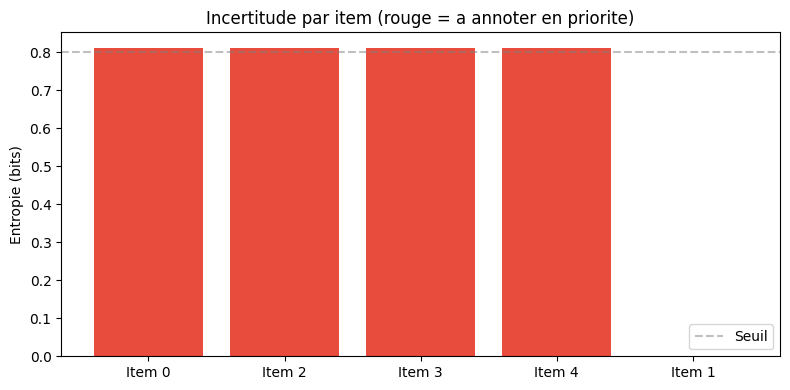

In [15]:
# Apprentissage actif : uncertainty sampling

print("=== Apprentissage Actif ===")
print("\nSelection des items les plus incertains :")

incertitudes = []
for i in range(n_items):
    votes = labels[i]
    n0 = np.sum(votes == 0)
    n1 = np.sum(votes == 1)
    p0 = n0 / n_workers
    p1 = n1 / n_workers
    
    # Entropie binaire
    entropie = 0
    if p0 > 0:
        entropie -= p0 * np.log2(p0)
    if p1 > 0:
        entropie -= p1 * np.log2(p1)
    
    incertitudes.append((i, entropie))
    print(f"Item {i} : votes [0:{n0}, 1:{n1}], entropie = {entropie:.3f} bits"
          f"{'  <- incertain' if entropie > 0.8 else ''}")

# Trier par entropie decroissante
incertitudes.sort(key=lambda x: x[1], reverse=True)
print(f"\nItems a annoter en priorite (plus incertains) :")
for rank, (item, ent) in enumerate(incertitudes[:3]):
    print(f"  {rank+1}. Item {item} (entropie = {ent:.3f} bits)")

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
items_sorted = [x[0] for x in incertitudes]
ent_sorted = [x[1] for x in incertitudes]
colors = ['#e74c3c' if e > 0.8 else '#3498db' for e in ent_sorted]
ax.bar([f"Item {i}" for i in items_sorted], ent_sorted, color=colors)
ax.set_ylabel("Entropie (bits)")
ax.set_title("Incertitude par item (rouge = a annoter en priorite)")
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Seuil')
ax.legend()
plt.tight_layout()
plt.show()

### Analyse de l'apprentissage actif

L'entropie mesure l'incertitude du modèle sur le vrai label de chaque item. Les items avec une entropie elevee sont ceux ou les workers sont en desaccord. En les annotant en priorite (par exemple en demandant l'avis d'un expert supplementaire), on maximise le gain d'information.

## 8. Exemple guide : Crowdsourcing d'Images

Simulons un scénario de classification d'images (chat/chien) avec 8 annotateurs de qualites variables.

In [16]:
# Exemple guide : Crowdsourcing d'images
np.random.seed(42)

n_images = 10
n_annotateurs = 8

# Vrais labels (0=chat, 1=chien)
vrais_labels_img = np.random.randint(0, 2, size=n_images)

# Qualites des annotateurs (variables)
qualites = np.array([0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.55, 0.50])

# Generer les annotations
annotations = np.zeros((n_images, n_annotateurs), dtype=int)
for i in range(n_images):
    for a in range(n_annotateurs):
        if np.random.random() < qualites[a]:
            annotations[i, a] = vrais_labels_img[i]
        else:
            annotations[i, a] = 1 - vrais_labels_img[i]

print("=== Crowdsourcing Images (Chat=0 / Chien=1) ===")
print(f"\n{len(qualites)} annotateurs, qualites : {', '.join([f'{q:.2f}' for q in qualites])}")

# Afficher les annotations
header = "Image :  " + "  ".join([f"A{a+1}" for a in range(n_annotateurs)]) + "  Vrai"
print(header)
for i in range(n_images):
    row = f"  {i:2d}    : " + "  ".join([f" {annotations[i,a]}" for a in range(n_annotateurs)])
    row += f"   {vrais_labels_img[i]}"
    print(row)

# Comparaison vote majoritaire vs Dawid-Skene
print("\n--- Vote Majoritaire ---")
pred_mv = np.array([1 if np.sum(annotations[i]) > n_annotateurs / 2 else 0
                     for i in range(n_images)])
acc_mv = np.mean(pred_mv == vrais_labels_img)
print(f"Precision vote majoritaire : {acc_mv:.1%}")

print("\n--- Dawid-Skene ---")
# Reinitialiser et executer
confusion_matrices_init = np.ones((n_annotateurs, 2, 2)) * 0.5
confusion_matrices_init[:, 0, 0] = 0.7
confusion_matrices_init[:, 1, 1] = 0.7
confusion_matrices_init[:, 0, 1] = 0.3
confusion_matrices_init[:, 1, 0] = 0.3
confusion_matrices = confusion_matrices_init.copy()

class_probs_img, confusion_img = dawid_skene_em(annotations, n_classes=2)
pred_ds = np.argmax(class_probs_img, axis=1)
acc_ds = np.mean(pred_ds == vrais_labels_img)
print(f"Precision Dawid-Skene : {acc_ds:.1%}")

print(f"\nComparaison : MV={acc_mv:.1%} vs DS={acc_ds:.1%}")
if acc_ds > acc_mv:
    print("Le modele Dawid-Skene surpasse le vote majoritaire.")
elif acc_ds == acc_mv:
    print("Les deux methodes ont la meme precision sur ce jeu de donnees.")
else:
    print("Le vote majoritaire est suffisant sur ce petit jeu de donnees.")

=== Crowdsourcing Images (Chat=0 / Chien=1) ===

8 annotateurs, qualites : 0.95, 0.90, 0.85, 0.80, 0.70, 0.60, 0.55, 0.50
Image :  A1  A2  A3  A4  A5  A6  A7  A8  Vrai
   0    :  0   0   1   0   1   0   1   1   0
   1    :  1   1   1   1   1   1   1   0   1
   2    :  0   0   0   0   1   0   0   1   0
   3    :  0   0   0   0   1   1   1   0   0
   4    :  0   0   0   0   0   0   1   0   0
   5    :  1   1   1   1   1   0   0   0   1
   6    :  0   0   1   0   0   0   0   0   0
   7    :  0   0   0   0   0   0   1   0   0
   8    :  1   0   0   0   1   1   1   1   0
   9    :  1   1   1   0   1   1   1   1   1

--- Vote Majoritaire ---
Precision vote majoritaire : 90.0%

--- Dawid-Skene ---
Convergence a l'iteration 10
Precision Dawid-Skene : 90.0%

Comparaison : MV=90.0% vs DS=90.0%
Les deux methodes ont la meme precision sur ce jeu de donnees.


### Analyse de l'exemple crowdsourcing d'images

Cet exemple illustre un scénario realiste avec des annotateurs de qualite variable. Le modèle Dawid-Skene peut surperformer le vote majoritaire quand les workers de mauvaise qualite sont nombreux, car il apprend leurs biais et les sous-pondere automatiquement.

## 9. Resume : Infer.NET vs PyMC pour le Crowdsourcing

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| **Inference** | Message passing (EP/VMP) | MCMC (CategoricalGibbsMetropolis pour labels discrets) ; EM hand-rolled (Dawid-Skene) utilise ici pour la stabilite |
| **Modèle Honest Worker** | Direct (Variable.Bernoulli) | Beta-Bernoulli conjugee |
| **Modèle Biased Worker** | VariableArray + Dirichlet | EM (Dawid-Skene) ou MCMC |
| **Modèle hiérarchique** | Variables imbriquees | Modèles imbriques PyMC |
| **Active Learning** | Entropie posterieure | Entropie sur trace MCMC |
| **Visualisation** | Factor graphs | ArviZ, matplotlib |

> **Note sur l'inference** : NUTS ne peut pas echantillonner les variables latentes discretes (`Categorical` comme les vrais labels) — PyMC utilise `CategoricalGibbsMetropolis` (ou un `CompoundStep`) pour celles-ci. PyMC ne fournit pas d'EM natif : l'implementation EM de ce notebook est codée a la main (cellule EM Dawid-Skene), ce qui est legitime car l'EM est la méthode *originale* de Dawid & Skene (1979) et reste plus stable que le MCMC sur les petits jeux de données d'annotation.

### Guide de choix des modèles

| Critere | Vote majoritaire | Honest Worker | Biased Worker | Community |
|---------|-----------------|---------------|---------------|-----------|
| Simplicite | +++ | ++ | + | - |
| Robustesse aux biais | - | + | +++ | +++ |
| Données necessaires | Aucune | Peu | Moyen | Beaucoup |
| Scalabilite | Excellente | Bonne | Moyenne | Faible |

### Applications industrielles

| Domaine | Application |
|---------|------------|
| Annotation d'images | Labelisation pour vision par ordinateur |
| Analyse de sentiment | Classification de texte par des annotateurs |
| Sante | Diagnostic multi-praticiens |
| Moderation | Classification de contenu par des moderateurs |

## 10. Exercice : Crowdsourcing avec Expertise Variable

Simulez un scénario de crowdsourcing avec **3 experts** (qualite ~0.90) et **5 novices** (qualite ~0.60), pour classer 6 images.

**Étapes** :
1. Generer les labels synthetiques en tenant compte des qualites par groupe
2. Définir des priors différents pour les experts vs les novices
3. Construire un modèle Dawid-Skene simplifie
4. Comparer la precision du modèle avec le vote majoritaire

In [17]:
# TODO etudiant : implementer le crowdsourcing avec expertise variable
#
# Etape 1 : Generer les labels synthetiques
# - 3 experts (qualite ~0.90) et 5 novices (qualite ~0.60)
# - 6 images avec vrais labels aleatoires (0 ou 1)
#
# Etape 2 : Definir des priors Beta differents par groupe
# - Experts : Beta(9, 1) (haute precision attendue)
# - Novices : Beta(3, 2) (precision moderee attendue)
#
# Etape 3 : Construire le modele Dawid-Skene simplifie
# - Utiliser la fonction dawid_skene_em definie plus haut
#
# Etape 4 : Comparer precision Dawid-Skene vs vote majoritaire

print("Exercice a completer : Crowdsourcing avec expertise variable")
print("Indice : reutilisez la fonction dawid_skene_em et le pattern")
print("de generation synthetique de la section 8.")

Exercice a completer : Crowdsourcing avec expertise variable
Indice : reutilisez la fonction dawid_skene_em et le pattern
de generation synthetique de la section 8.


## Conclusion

Le crowdsourcing bayesien modelise la fiabilite des annotateurs et infere la verite sous-jacente a partir de reponses multiples et potentiellement bruitees.

### Points cles
- Le modèle de Dawid-Skene estime la matrice de confusion de chaque annotateur
- L'inference bayesienne quantifie l'incertitude sur les labels vrais
- PyMC permet d'etendre le modèle avec des priors hiérarchiques sur les annotateurs

***

**Retour au sommaire** : [Index Probas](../README.md)

**Navigation** : [<< PyMC-12](PyMC-12-Modeles-Hierarchiques.ipynb) | [PyMC-14 >>](PyMC-14-Sequences.ipynb)


## References

- **Dawid, A. P. and Skene, A. M. (1979).** *Maximum Likelihood Estimation of Observer Error-Rates Using the EM Algorithm.* Journal of the Royal Statistical Society. Series C (Applied Statistics), 28(1), 20-28. doi:10.2307/2346806 — Le modèle originel des matrices de confusion par annotateur et de l'inference par EM utilise dans ce notebook.
- Raymond, M. (prelude moderne) : Dawid-Skene demeure la reference pour l'agregation de labels en crowdsourcing ; les variants hiérarchiques (Community) generalisent l'idee a des groupes d'annotateurs de fiabilite partagee.